In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error

In [2]:
# Reading the CSV file into a DataFrame
df = pd.read_csv('/Users/alanphan/Documents/WGU MSDA/D614/D614 Project/data/medical_clean.csv')
df

,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,...,TotalCharge,Additional_charges,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
0,1,C412403,8cd49b13-f45a-4b47-a2bd-173ffa932c2f,3a83ddb66e2ae73798bdf1d705dc0932,Eva,AL,Morgan,35621,34.34960,-86.72508,...,3726.702860,17939.403420,3,3,2,2,4,3,3,4
1,2,Z919181,d2450b70-0337-4406-bdbb-bc1037f1734c,176354c5eef714957d486009feabf195,Marianna,FL,Jackson,32446,30.84513,-85.22907,...,4193.190458,17612.998120,3,4,3,4,4,4,3,3
2,3,F995323,a2057123-abf5-4a2c-abad-8ffe33512562,e19a0fa00aeda885b8a436757e889bc9,Sioux Falls,SD,Minnehaha,57110,43.54321,-96.63772,...,2434.234222,17505.192460,2,4,4,4,3,4,3,3
3,4,A879973,1dec528d-eb34-4079-adce-0d7a40e82205,cd17d7b6d152cb6f23957346d11c3f07,New Richland,MN,Waseca,56072,43.89744,-93.51479,...,2127.830423,12993.437350,3,5,5,3,4,5,5,5
4,5,C544523,5885f56b-d6da-43a3-8760-83583af94266,d2f0425877b10ed6bb381f3e2579424a,West Point,VA,King William,23181,37.59894,-76.88958,...,2113.073274,3716.525786,2,1,3,3,5,3,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,B863060,a25b594d-0328-486f-a9b9-0567eb0f9723,39184dc28cc038871912ccc4500049e5,Norlina,NC,Warren,27563,36.42886,-78.23716,...,6850.942000,8927.642000,3,2,2,3,4,3,4,2
9996,9997,P712040,70711574-f7b1-4a17-b15f-48c54564b70f,3cd124ccd43147404292e883bf9ec55c,Milmay,NJ,Atlantic,8340,39.43609,-74.87302,...,7741.690000,28507.150000,3,3,4,2,5,3,4,4
9997,9998,R778890,1d79569d-8e0f-4180-a207-d67ee4527d26,41b770aeee97a5b9e7f69c906a8119d7,Southside,TN,Montgomery,37171,36.36655,-87.29988,...,8276.481000,15281.210000,3,3,3,4,4,2,3,2
9998,9999,E344109,f5a68e69-2a60-409b-a92f-ac0847b27db0,2bb491ef5b1beb1fed758cc6885c167a,Quinn,SD,Pennington,57775,44.10354,-102.01590,...,7644.483000,7781.678000,5,5,3,4,4,3,4,3


In [3]:
# Filtering DataFrame to the 13 key variables
columns_to_keep = [
    # Outcome variable
    'TotalCharge',
    # 3 Modifiable interventions (Levers)
    'vitD_supp', 'Full_meals_eaten', 'Doc_visits',
    # 6 Clinical variables (Intermediates)
    'VitD_levels', 'Diabetes', 'Overweight', 'HighBlood', 'Hyperlipidemia', 'Complication_risk',
    # 3 Demographic variables (Externals)
    'Age', 'Gender', 'Income'
]

df = df[columns_to_keep].copy()
df.head()

,TotalCharge,vitD_supp,Full_meals_eaten,Doc_visits,VitD_levels,Diabetes,Overweight,HighBlood,Hyperlipidemia,Complication_risk,Age,Gender,Income
0,3726.702860,0,0,6,19.141466,Yes,No,Yes,No,Medium,53,Male,86575.93
1,4193.190458,1,2,4,18.940352,No,Yes,Yes,No,High,51,Female,46805.99
2,2434.234222,0,1,4,18.057507,Yes,Yes,Yes,No,Medium,53,Female,14370.14
3,2127.830423,0,1,4,16.576858,No,No,No,No,Medium,78,Male,39741.49
4,2113.073274,2,0,5,17.439069,No,No,No,Yes,Low,22,Female,1209.56


In [4]:
# Looking at the data types of the variables
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TotalCharge        10000 non-null  float64
 1   vitD_supp          10000 non-null  int64  
 2   Full_meals_eaten   10000 non-null  int64  
 3   Doc_visits         10000 non-null  int64  
 4   VitD_levels        10000 non-null  float64
 5   Diabetes           10000 non-null  object 
 6   Overweight         10000 non-null  object 
 7   HighBlood          10000 non-null  object 
 8   Hyperlipidemia     10000 non-null  object 
 9   Complication_risk  10000 non-null  object 
 10  Age                10000 non-null  int64  
 11  Gender             10000 non-null  object 
 12  Income             10000 non-null  float64
dtypes: float64(3), int64(4), object(6)
memory usage: 1015.8+ KB


In [5]:
# Checking the names of the variables
df.columns

Index(['TotalCharge', 'vitD_supp', 'Full_meals_eaten', 'Doc_visits',
       'VitD_levels', 'Diabetes', 'Overweight', 'HighBlood', 'Hyperlipidemia',
       'Complication_risk', 'Age', 'Gender', 'Income'],
      dtype='object')

In [6]:
# Descriptive statistics
df.describe()

,TotalCharge,vitD_supp,Full_meals_eaten,Doc_visits,VitD_levels,Age,Income
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5312.172769,0.398900,1.001400,5.012200,17.964262,53.511700,40490.495160
std,2180.393838,0.628505,1.008117,1.045734,2.017231,20.638538,28521.153293
min,1938.312067,0.000000,0.000000,1.000000,9.806483,18.000000,154.080000
25%,3179.374015,0.000000,0.000000,4.000000,16.626439,36.000000,19598.775000
50%,5213.952000,0.000000,1.000000,5.000000,17.951122,53.000000,33768.420000
75%,7459.699750,1.000000,2.000000,6.000000,19.347963,71.000000,54296.402500
max,9180.728000,5.000000,7.000000,9.000000,26.394449,89.000000,207249.100000


In [7]:
# Checking if any variable has null values
df.isnull().sum()

TotalCharge          0
vitD_supp            0
Full_meals_eaten     0
Doc_visits           0
VitD_levels          0
Diabetes             0
Overweight           0
HighBlood            0
Hyperlipidemia       0
Complication_risk    0
Age                  0
Gender               0
Income               0
dtype: int64

In [8]:
# Checking if the DataFrame has any duplicate rows
df.duplicated().sum()

0

In [9]:
# Checking unique values in categorical columns
categorical_cols = ['Diabetes', 'Overweight', 'HighBlood', 'Hyperlipidemia', 'Complication_risk', 'Gender']
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

Diabetes: ['Yes' 'No']
Overweight: ['No' 'Yes']
HighBlood: ['Yes' 'No']
Hyperlipidemia: ['No' 'Yes']
Complication_risk: ['Medium' 'High' 'Low']
Gender: ['Male' 'Female' 'Nonbinary']


In [10]:
# Binary encoding for Yes/No variables
binary_cols = ['Diabetes', 'Overweight', 'HighBlood', 'Hyperlipidemia']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Ordinal encoding for Complication_risk
ordinal_encoder = OrdinalEncoder(categories = [['Low', 'Medium', 'High']])
df['Complication_risk'] = ordinal_encoder.fit_transform(df[['Complication_risk']])

# Dummy encoding for Gender using OneHotEncoder
onehot_encoder = OneHotEncoder(drop = 'first', sparse_output = False)
gender_encoded = onehot_encoder.fit_transform(df[['Gender']])
gender_cols = onehot_encoder.get_feature_names_out(['Gender'])

# Add encoded columns and drop original
df[gender_cols] = gender_encoded
df.drop('Gender', axis = 1, inplace = True)

# Viewing the results of the encoded columns
df[['Diabetes', 'Overweight', 'HighBlood', 'Hyperlipidemia', 'Complication_risk', 'Gender_Male', 'Gender_Nonbinary']].head()

,Diabetes,Overweight,HighBlood,Hyperlipidemia,Complication_risk,Gender_Male,Gender_Nonbinary
0,1,0,1,0,1.0,1.0,0.0
1,0,1,1,0,2.0,0.0,0.0
2,1,1,1,0,1.0,0.0,0.0
3,0,0,0,0,1.0,1.0,0.0
4,0,0,0,1,0.0,0.0,0.0


In [11]:
# Splitting up the DataFrame
X = df.drop('TotalCharge', axis = 1)
y = df['TotalCharge']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [12]:
# Scaling the independent variables
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train) # Calculating mean and std and apply to the training data
scaled_X_test = scaler.transform(X_test) # Using the same mean and std of scaled_X_train and applying to the test data
# Viewing the results of the scaling
scaled_X_train

array([[ 0.95811125, -0.98706919,  0.95015301, ..., -0.9329939 ,
         1.0536893 , -0.15041805],
       [-0.63376622,  0.00608306,  1.90460103, ..., -0.22156624,
         1.0536893 , -0.15041805],
       [-0.63376622,  0.9992353 ,  0.95015301, ..., -1.33457744,
         1.0536893 , -0.15041805],
       ...,
       [-0.63376622, -0.98706919, -0.00429502, ..., -0.02767066,
        -0.94904636, -0.15041805],
       [-0.63376622, -0.98706919, -0.00429502, ...,  1.36719377,
         1.0536893 , -0.15041805],
       [-0.63376622,  0.9992353 , -0.00429502, ...,  0.90077597,
        -0.94904636, -0.15041805]])

In [13]:
# LASSO with cross-validation
lasso_cv = LassoCV(cv = 5, random_state = 42)
lasso_cv.fit(scaled_X_train, y_train)

LassoCV(cv=5, random_state=42)

In [14]:
# Making predictions
y_train_pred = lasso_cv.predict(scaled_X_train)
y_test_pred = lasso_cv.predict(scaled_X_test)

In [15]:
# Evaluating performance
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

print(f"Optimal alpha: {lasso_cv.alpha_}")
print(f"Training RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")

Optimal alpha: 48.33812721422774
Training RMSE: 2180.11
Test RMSE: 2164.70


In [16]:
# Actual TotalCharge vs. Predicted TotalCharge
actual_vs_predicted = pd.DataFrame({'Actual TotalCharge': y_test, 'Predicted TotalCharge': y_test_pred, 'Difference': y_test - y_test_pred})
actual_vs_predicted

,Actual TotalCharge,Predicted TotalCharge,Difference
6252,6060.700000,5307.644405,753.055595
4684,3255.814455,5308.791748,-2052.977293
1731,2844.703206,5406.917876,-2562.214670
4742,3133.944906,5210.665620,-2076.720714
4521,4125.009552,5209.518277,-1084.508725
...,...,...,...
6412,8219.890000,5307.644405,2912.245595
8285,5612.595000,5209.518277,403.076723
7853,8622.724000,5209.518277,3413.205723
1095,2890.340759,5307.644405,-2417.303646


In [17]:
# Getting feature names and coefficients
feature_names = X_train.columns
coefficients = lasso_cv.coef_

# Create coefficient DataFrame
coef_df = pd.DataFrame({'Feature': feature_names,'Coefficient': coefficients}).sort_values('Coefficient', key = abs, ascending = False)
# Cleaning up the coefficients with -0.0 values
coef_df['Coefficient'] = coef_df['Coefficient'] + 0.0

print("LASSO Coefficients (sorted by absolute value):")
print(coef_df)

LASSO Coefficients (sorted by absolute value):
              Feature  Coefficient
8   Complication_risk    71.390345
6           HighBlood     0.563497
0           vitD_supp     0.000000
1    Full_meals_eaten     0.000000
2          Doc_visits     0.000000
3         VitD_levels     0.000000
4            Diabetes     0.000000
5          Overweight     0.000000
7      Hyperlipidemia     0.000000
9                 Age     0.000000
10             Income     0.000000
11        Gender_Male     0.000000
12   Gender_Nonbinary     0.000000


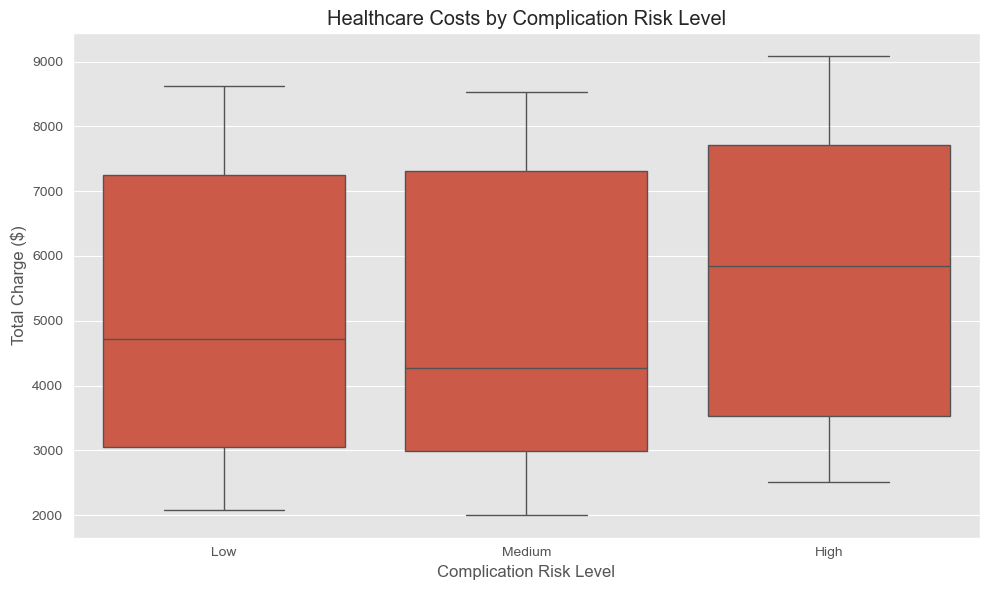

Average Healthcare Costs by Complication Risk Level:
            Mean Cost ($)  Count
Risk_Level                      
High              5611.92    687
Low               5144.93    440
Medium            5086.98    873


In [18]:
# Mapping the ordinal encoded values back to original categories for interpretation
risk_mapping = {0: 'Low', 1: 'Medium', 2: 'High'}

# Creating a copy of test data with readable risk levels
test_data = X_test.copy()
test_data['TotalCharge'] = y_test
test_data['Risk_Level'] = test_data['Complication_risk'].map(risk_mapping)

# Box plot of TotalCharge by Complication_risk
plt.figure(figsize = (10, 6))
sns.boxplot(data = test_data, x = 'Risk_Level', y = 'TotalCharge', order = ['Low', 'Medium', 'High'])
plt.title('Healthcare Costs by Complication Risk Level')
plt.xlabel('Complication Risk Level')
plt.ylabel('Total Charge ($)')
plt.tight_layout()
plt.show()

# Table of mean costs by complication risk
cost_summary = test_data.groupby('Risk_Level')['TotalCharge'].agg(['mean', 'count']).round(2)
cost_summary.columns = ['Mean Cost ($)', 'Count']
print("Average Healthcare Costs by Complication Risk Level:")
print(cost_summary)